## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Load Dataset

In [5]:
import os
print(os.getcwd())  # shows your current working directory

C:\Users\bhuva


In [6]:
# Load Bitcoin dataset
df = pd.read_csv("BTC-USD.csv")

# Display first rows
print(df.head())


         Date        Open        High         Low       Close   Adj Close  \
0  10-10-2014  364.687012  375.066986  352.963013  361.562012  361.562012   
1  11-10-2014  361.362000  367.191010  355.950989  362.299011  362.299011   
2  12-10-2014  362.605988  379.433014  356.144012  378.549011  378.549011   
3  13-10-2014  377.920990  397.226013  368.897003  390.414001  390.414001   
4  14-10-2014  391.691986  411.697998  391.324005  400.869995  400.869995   

       Volume  
0  43665700.0  
1  13345200.0  
2  17552800.0  
3  35221400.0  
4  38491500.0  


## Data Preprocessing

In [7]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [8]:
# Check missing values
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [9]:
# Drop rows with missing values
df = df.dropna()

In [10]:
# Set Date as index
df.set_index("Date", inplace=True)

## Feature Selection

In [11]:
# Target: Close price
# Features: Open, High, Low, Adj Close, Volume

In [12]:
X = df[["Open", "High", "Low", "Adj Close", "Volume"]]
y = df["Close"]

## Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

## Feature Scaling

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model Training (Linear Regression)

In [15]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Prediction

In [16]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 8.623640239499614e-12
MSE : 1.3846122981776982e-22
RMSE: 1.1766954993445408e-11
R2 Score: 1.0


## Visualization (Actual vs Predicted)

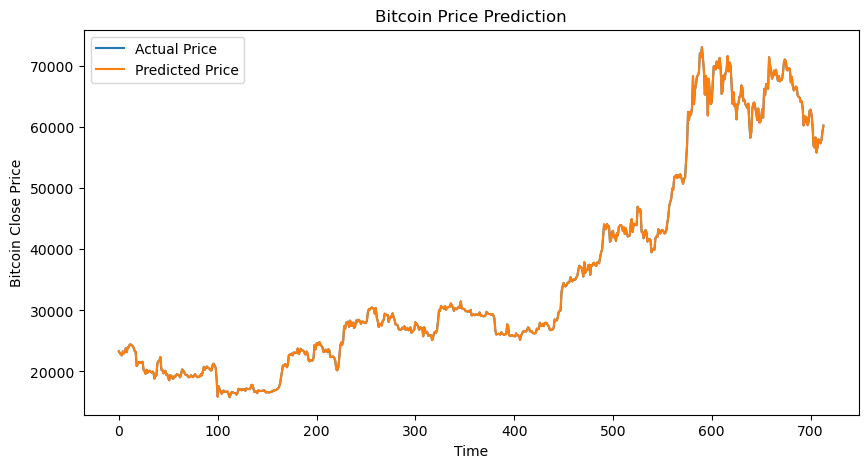

In [18]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Bitcoin Price Prediction")
plt.xlabel("Time")
plt.ylabel("Bitcoin Close Price")
plt.legend()
plt.show()


## Predict Future Price (Sample Input)

In [20]:
# Sample input (Open, High, Low, Adj Close, Volume)
sample = np.array([[43000, 43500, 42500, 43200, 35000000]])
sample_scaled = scaler.transform(sample)

predicted_price = model.predict(sample_scaled)
print("Predicted Bitcoin Close Price:", predicted_price[0])


Predicted Bitcoin Close Price: 43200.00000000002


C:\Users\bhuva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
print("R2 Score:", r2)

R2 Score: 1.0
